# BERT Approach

This notebook presents the bert based approach in solving the three way classification problem of clarity labeling

In [1]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from torch.optim import AdamW
import tqdm


### This only applies if user is using Google Drive ###

from google.colab import drive
import os

drive.mount('/content/drive')


# This assumes you have a folder named 'Colab_Project' in your 'My Drive'
DRIVE_PATH = '/content/drive/MyDrive/dataset'

os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"Drive mounted and directory checked at: {DRIVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and directory checked at: /content/drive/MyDrive/dataset


In [2]:

dataset_path = f'{DRIVE_PATH}/training_data_processed.csv'
df = pd.read_csv(dataset_path)

# drop_cols = ['evasion_label', 'Unnamed: 0', 'affirmative_questions']
# df = df.drop(columns= drop_cols)
df.head()

,Unnamed: 0,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,affirmative_questions,clarity_label,evasion_label
0,0,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,False,Clear Reply,Explicit
1,1,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,False,Ambivalent,General
2,2,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,False,Ambivalent,Partial/half-answer
3,3,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Are you worried about the meeting between Pre...,False,Ambivalent,Dodging
4,4,3,"Q. I can imagine. It is evening, I'd like to r...","Well, I hope I get to see Mr. Xi sooner than l...",The question consists of 3 parts:\n1. Is the P...,Question part: 1. Is the President's engagemen...,Is the President's engagement with Asian coun...,False,Clear Reply,Explicit


In [3]:
label_map = {
    'Clear Reply': 0,
    'Clear Non-Reply': 1,
    'Ambivalent': 2
}


In [4]:
def data_prep(questions, answers, clarity_label):
    encodings = tokenizerBert(questions.tolist(),
                          answers.tolist(),
                          padding= True,
                          truncation = True,
                          max_length = 512,
                          return_tensors = 'pt'
                          )
    label_tensors = torch.tensor([label_map[l] for l in clarity_label.tolist()])
    dataset = TensorDataset(
        encodings['input_ids'],
        encodings['attention_mask'],
        encodings['token_type_ids'],
        label_tensors
        )
    return dataset


kör :

pip install -U bitsandbytes transformers accelerate


In [ ]:
from huggingface_hub import login

login()

In [ ]:

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "meta-llama/Meta-Llama-3-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    token=True
)

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [ ]:
SYSTEM_PROMPT = """
You are a highly accurate text extraction assistant. Your task is to analyze a long interview answer and a specific subquestion.

You must identify the exact sentence or sentences within the provided interview answer that directly address the subquestion.

If the subquestion is not answered, return only the phrase "NOT_ANSWERED".

Do not paraphrase, summarize, or add any extra commentary. Return only the extracted text or the "NOT_ANSWERED" phrase.
"""

SYSTEM_PROMPT_SUMMARY = """
You are a precise extraction and summarization assistant.

You receive:
- A subquestion (Question)
- A long interview answer (Answer)

Task:
1. Find only the part(s) of the Answer that directly address the Question.
2. Ignore unrelated digressions.
3. Write a concise, neutral summary of that relevant part only.

Output format (exactly):
<your summary>
"""

def get_answers_llama3(question, full_answer, SYSTEM_PROMPT = SYSTEM_PROMPT):
    user_prompt = f"""
Subquestion: "{question}"

Full Interview Answer:
---
{full_answer}
---

Summary:
"""

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt}
    ]

    model_inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_tensors = model.generate(
            model_inputs,
            max_new_tokens=256,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    output_text = tokenizer.decode(output_tensors[0][model_inputs.shape[1]:], skip_special_tokens=True).strip()
    return output_text

# Example test before running on the full dataframe
test_q = "What is the policy?"
test_a = "Our policy is clearly defined in section 3. We updated it last year after feedback."
print(f"Extracted: {get_answers_llama3(test_q, test_a, SYSTEM_PROMPT_SUMMARY)}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Extracted: "Our policy is clearly defined in section 3."


In [ ]:
import os
from tqdm.auto import tqdm

processed_df = df.copy()
processed_df['answer'] = None # Initialize a new column

# Define where to save checkpoints
CHECKPOINT_FILE = f'{DRIVE_PATH}/ckpt_test_summary.csv'
CHECKPOINT_INTERVAL = 200
DISPLAY_INTERVAL = 100

if os.path.exists(CHECKPOINT_FILE):
    print(f"Checkpoint found. Resuming from {CHECKPOINT_FILE}")
    processed_df = pd.read_csv(CHECKPOINT_FILE)
    last_processed_index = processed_df['answer'].last_valid_index()
    if last_processed_index is not None:
        start_index = last_processed_index + 1
    else:
        start_index = 0
else:
    start_index = 0


print(f"Starting extraction from entry {start_index} of {len(processed_df)}")

for index, row in tqdm(processed_df.iloc[start_index:].iterrows(), total=len(processed_df.iloc[start_index:])):

    question = row['question']
    interview_answer = row['interview_answer']

    extracted_text = get_answers_llama3(question, interview_answer, SYSTEM_PROMPT_SUMMARY)

    processed_df.at[index, 'answer'] = extracted_text

    if (index + 1) % DISPLAY_INTERVAL == 0:
        print(f"\n--- Sample Display at Entry {index + 1} ---")
        print(f"Question: {question[:100]}...")
        print(f"Full Answer (Snippet): {interview_answer[:150]}...")
        print(f"**Extracted Answer:** {extracted_text}")
        print("------------------------------------------")


    if (index + 1) % CHECKPOINT_INTERVAL == 0:
        processed_df.to_csv(CHECKPOINT_FILE, index=False)
        print(f"\nCheckpoint saved at entry {index + 1}.")

print("Processing complete!")

FINAL_FILE_NAME = 'training_data_preprocessed_LLM_summary.csv'
processed_df.to_csv(FINAL_FILE_NAME, index=False)
print(f"Final data saved to {FINAL_FILE_NAME}")


Starting extraction from entry 0 of 308


  0%|          | 0/308 [00:00<?, ?it/s]


--- Sample Display at Entry 100 ---
Question: What kind of punishment would you like to see imposed on North Korea, short of some sort of condemna...
Full Answer (Snippet): Okay....
**Extracted Answer:** "Economic sanctions, such as cutting off trade and restricting access to international financial systems, would be an effective punishment for North Korea, as it would severely impact their ability to fund their military and nuclear programs."
------------------------------------------

--- Sample Display at Entry 200 ---
Question: Do you agree with the Prime Minister's supporters that he led the way on the issue?...
Full Answer (Snippet): Well, on your second question, Mr. McKinnon, we have proceeded through all the processes required under our extradition agreements. It is now in the h...
**Extracted Answer:** The relevant part of the answer that directly addresses the question "Do you agree with the Prime Minister's supporters that he led the way on the issue?" is:

"I totally unde

In [11]:

from sklearn.model_selection import train_test_split

EVASION = True
CLARITY_LABEL = 'Clear Non-Reply'


### Paths need to be modified to fit the setup of the user ###
### Paths can be adjusted according to dataset preference ###
path_summary = '/content/training_data_preprocessed_LLM_summary.csv'
path_exctracted = '/content/drive/MyDrive/dataset/training_data_preprocessed_LLM.csv'
path_regular = '/content/drive/MyDrive/dataset/training_data_processed.csv'

df = pd.read_csv(path_regular)

if EVASION:
  df = df[df["clarity_label"] == CLARITY_LABEL]
  if CLARITY_LABEL == 'Ambivalent':
    label_map = {
        'Implicit': 0,
        'Dodging': 1,
        'General': 2,
        'Deflection':3,
        'Partial/half-answer':4
    }
  elif CLARITY_LABEL == 'Clear Non-Reply':
    label_map = {
        'Declining to answer': 0,
        'Claims ignorance': 1,
        'Clarification': 2,
    }

num_labels = len(label_map)
model_name = 'bert-base-uncased'
modelBert = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
tokenizerBert = BertTokenizer.from_pretrained(model_name)
Q_train, Q_val, A_train, A_val, L_train, L_val = train_test_split(
    df['question'],
    df['interview_answer'],
    df['evasion_label'], ## change to 'clarity-label' for task one
    test_size=0.2,
    random_state=40
    )
BATCH_SIZE = 16

train_dataset = data_prep(Q_train, A_train, L_train)
val_dataset = data_prep(Q_val, A_val, L_val)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens 

### Model Training

With preprocessing done we can now gop on to build the training loop to finetune the BERT model

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, classification_report



model = modelBert

def eval_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids, attention_mask, token_type_ids, labels = [t.to(device) for t in batch]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )

            _, predicted = torch.max(outputs.logits, 1)


            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    model.train()

    accuracy = 100 * np.sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    class_report = classification_report(all_labels, all_predictions, digits=4, output_dict=True)

    return accuracy, f1_weighted, conf_matrix, class_report


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
epochs = 5
optimizer = AdamW(model.parameters(), lr = 5e-5)



for epoch in range(epochs):
    print(f"--- Starting Epoch {epoch+1}/{epochs} ---")
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        token_type_ids = batch[2].to(device)
        labels = batch[3].to(device)

        model.zero_grad()

        outputs = model(input_ids= input_ids,
                        attention_mask = attention_mask,
                        token_type_ids = token_type_ids,
                        labels = labels
                        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    val_accuracy, val_f1, val_conf_matrix, val_report = eval_model(model, val_loader, device)

    print(f"Epoch {epoch+1} Summary:")
    print(f"  Training Loss: {avg_train_loss:.4f}")
    print(f"  Validation Accuracy: {val_accuracy:.2f}%")
    print(f"  Validation F1 (Weighted): {val_f1:.4f}")

print("\n  --- Confusion Matrix (Validation) ---")
labels_list = list(label_map.keys())
cm_df = pd.DataFrame(val_conf_matrix, index=labels_list, columns=labels_list)
print(cm_df)

--- Starting Epoch 1/5 ---
Epoch 1 Summary:
  Training Loss: 1.0041
  Validation Accuracy: 61.11%
  Validation F1 (Weighted): 0.6084
--- Starting Epoch 2/5 ---
Epoch 2 Summary:
  Training Loss: 0.6591
  Validation Accuracy: 75.00%
  Validation F1 (Weighted): 0.7478
--- Starting Epoch 3/5 ---
Epoch 3 Summary:
  Training Loss: 0.4078
  Validation Accuracy: 70.83%
  Validation F1 (Weighted): 0.7004
--- Starting Epoch 4/5 ---
Epoch 4 Summary:
  Training Loss: 0.1916
  Validation Accuracy: 72.22%
  Validation F1 (Weighted): 0.7236
--- Starting Epoch 5/5 ---
Epoch 5 Summary:
  Training Loss: 0.0976
  Validation Accuracy: 73.61%
  Validation F1 (Weighted): 0.7383

  --- Confusion Matrix (Validation) ---
                     Declining to answer  Claims ignorance  Clarification
Declining to answer                   22                 8              2
Claims ignorance                       1                20              3
Clarification                          2                 3             1

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Test examples after gold-label filtering: 23

Test accuracy (gold labels): 60.87%

=== TEST SET PERFORMANCE (Gold Labels) ===
Correct predictions: 14/23
Total Accuracy: 60.87%

=== Classification report (test / gold labels) ===
                     precision    recall  f1-score   support

Declining to answer     0.6154    0.7273    0.6667        11
   Claims ignorance     0.5714    0.5000    0.5333         8
      Clarification     0.6667    0.5000    0.5714         4

           accuracy                         0.6087        23
          macro avg     0.6178    0.5758    0.5905        23
       weighted avg     0.6090    0.6087    0.6037        23



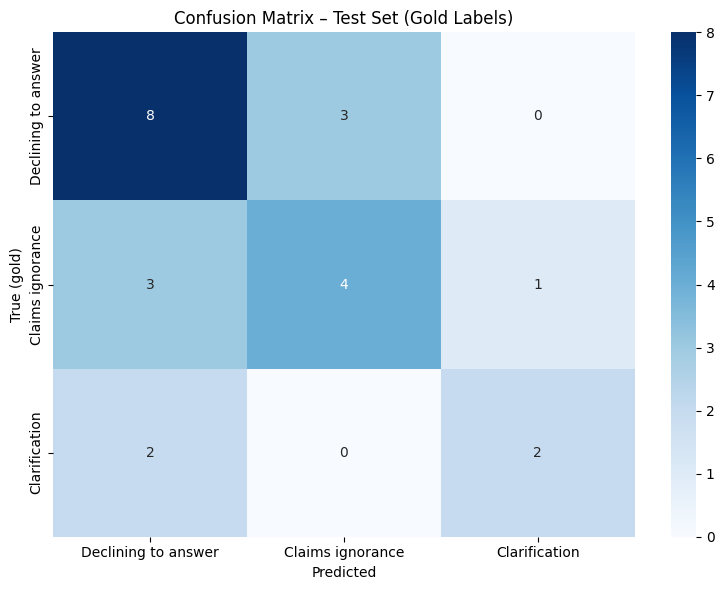

In [14]:
# === Test set evaluation with gold labels (separate cell) ===

import numpy as np
import pandas as pd
from collections import Counter
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load test set  ---------------------------------------------
# TODO: change this path to your actual test CSV
test_path = '/content/drive/MyDrive/dataset/test_data.csv'
df_test = pd.read_csv(test_path)

# Columns containing the three annotators' labels
# TODO: change to your real column names
annotator_cols = ['annotator1', 'annotator2', 'annotator3']


# 2. Build gold label via majority vote -------------------------
def majority_gold(row):
    labels = [row[c] for c in annotator_cols if pd.notna(row[c])]
    if not labels:
        return np.nan

    value, count = Counter(labels).most_common(1)[0]
    # require at least 2 annotators to agree
    return value if count >= 2 else np.nan

df_test['gold_label'] = df_test.apply(majority_gold, axis=1)

# Keep only rows where gold label exists AND is in label_map
df_test = df_test[df_test['gold_label'].isin(label_map.keys())].copy()
print("Test examples after gold-label filtering:", len(df_test))


# 3. Build DataLoader using your existing data_prep -------------
Q_test = df_test['question']
A_test = df_test['interview_answer']
L_test = df_test['gold_label']   # strings that match keys in label_map

test_dataset = data_prep(Q_test, A_test, L_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 4. Run model on test set --------------------------------------
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, token_type_ids, labels = [t.to(device) for t in batch]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

test_acc = (all_labels == all_preds).mean() * 100
print(f"\nTest accuracy (gold labels): {test_acc:.2f}%")

correct = (all_labels == all_preds).sum()
total = len(all_labels)
test_acc = correct / total * 100

print("\n=== TEST SET PERFORMANCE (Gold Labels) ===")
print(f"Correct predictions: {correct}/{total}")
print(f"Total Accuracy: {test_acc:.2f}%")
# 5. Classification report --------------------------------------
# Make sure label ordering matches the integer IDs in label_map
idx2label = {v: k for k, v in label_map.items()}
target_names = [idx2label[i] for i in range(len(idx2label))]

print("\n=== Classification report (test / gold labels) ===")
print(classification_report(
    all_labels,
    all_preds,
    target_names=target_names,
    digits=4
))


# 6. Confusion matrix with seaborn ------------------------------
cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(idx2label))))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel('Predicted')
plt.ylabel('True (gold)')
plt.title('Confusion Matrix – Test Set (Gold Labels)')
plt.tight_layout()
plt.show()